## Import Libraries for Heatmap generation

1) Plot without clustering
2) Split each feature into 3 different layers:
	1) Spatial, Texture, Intensity
	2) Cell Region
	3) SER-edge or STAR feature

#### z-scores: blue=low, white=mean, red=high.

In [8]:
import pandas as pd
import seaborn as sns
from matplotlib import pyplot as plt
import numpy as np
import re
from matplotlib.patches import Patch

In [9]:
rng = np.random.default_rng(seed=42)

In [10]:
from sklearn.preprocessing import StandardScaler

# Initialise Data Path

In [11]:
data_path = 'data/Raw_Data_Batch1_LAB1_CTX2.csv'
counts = pd.read_csv(data_path)
counts = counts.drop(columns=[
                   	"Row",
                    "Column",
                    "Timepoint",
                    "Field",
                    "Object No",
                    "X",
                    "Y",
                    "Bounding Box",
                    "Batch",
                    "Nuclei - Object No in Nuclei_all",
                    "Cellline ID"
                   ])
# Double check here
counts = counts.drop(columns=[
    'Position X [Âµm]',
	'Position Y [Âµm]',
    'Compound',
    'Concentration',
    'Cell Count'
])
counts = counts[counts["Cell Type"].isin(['LRRK2', 'Control'])]
print("counts (before): ", counts.shape)
counts = counts.fillna(0)
print("counts (after): ", counts.shape)

counts (before):  (8619, 1321)
counts (after):  (8619, 1321)


### For filtering specific variants

In [12]:
counts.head()

,Cell Type,Lysosome Intensity - Nucleus region Mean,Lysosome Intensity - Nucleus region StdDev,Lysosome Intensity - Nucleus region Median,Lysosome Intensity - Nucleus region Maximum,Lysosome Intensity - Nucleus region Minimum,Lysosome Intensity - Nucleus region Sum,Lysosome Intensity - Nucleus region CV [%],Lysosome Intensity - Nucleus region Quantile 90%,Lysosome Intensity - Nucleus region Contrast,...,Mitochondria Texture - Outer region SER Valley 1 px,Mitochondria Texture - Outer region SER Saddle 1 px,Mitochondria Texture - Outer region SER Bright 1 px,Mitochondria Texture - Outer region SER Dark 1 px,Mitochondria Texture - Outer region Haralick Correlation 2 px,Mitochondria Texture - Outer region Haralick Contrast 2 px,Mitochondria Texture - Outer region Haralick Sum Variance 2 px,Mitochondria Texture - Outer region Haralick Homogeneity 2 px,Mitochondria Texture - Outer region Gabor Min 2 px w2,Mitochondria Texture - Outer region Gabor Max 2 px w2
0,Control,1964.49,473.458,2001,2964,747,1092250,24.1009,2558,0.547062,...,0.062429,0.055786,0.060275,0.080337,0.692103,0.179664,0.246843,0.195137,0.000550,0.004230
1,Control,2582.91,555.290,2683,3507,1303,883355,21.4986,3261,0.674363,...,0.056252,0.055994,0.062334,0.067784,0.661050,0.187395,0.229586,0.210063,0.000543,0.004167
2,Control,3105.96,806.695,2904,6924,1006,2963080,25.9725,4097,0.466701,...,0.047268,0.060245,0.063949,0.054644,0.708571,0.196272,0.287673,0.203688,0.000483,0.003577
3,Control,1677.06,552.588,1557,3253,779,753001,32.9498,2438,0.286715,...,0.084388,0.079462,0.080827,0.100119,0.681948,0.367140,0.485384,0.179421,0.000649,0.005440
4,Control,3321.61,796.328,3175,9111,1523,4354630,23.9741,4097,0.425068,...,0.057507,0.053676,0.054210,0.068928,0.770866,0.165035,0.318869,0.227847,0.000484,0.003702


### Calculate Aggregate level values

In [13]:
cell_line_agg_df = counts.groupby(['Cell Type']).mean()
print("cell_line_agg (before): ", cell_line_agg_df.shape)
print("cell_line_agg (after): ", cell_line_agg_df.shape)

cell_line_agg (before):  (2, 1320)
cell_line_agg (after):  (2, 1320)


### Generate Heatmap without clustering

In [14]:
heatmap_data = cell_line_agg_df
sorted_columns = sorted(heatmap_data.columns, key=lambda x: (re.split(r'\W+', x)[0], re.split(r'\W+', x)[2], re.split(r'\W+', x)[1], re.split(r'\W+', x)[4]))
heatmap_data

,Lysosome Intensity - Nucleus region Mean,Lysosome Intensity - Nucleus region StdDev,Lysosome Intensity - Nucleus region Median,Lysosome Intensity - Nucleus region Maximum,Lysosome Intensity - Nucleus region Minimum,Lysosome Intensity - Nucleus region Sum,Lysosome Intensity - Nucleus region CV [%],Lysosome Intensity - Nucleus region Quantile 90%,Lysosome Intensity - Nucleus region Contrast,General Dimension - Nucleus region Area µm²,...,Mitochondria Texture - Outer region SER Valley 1 px,Mitochondria Texture - Outer region SER Saddle 1 px,Mitochondria Texture - Outer region SER Bright 1 px,Mitochondria Texture - Outer region SER Dark 1 px,Mitochondria Texture - Outer region Haralick Correlation 2 px,Mitochondria Texture - Outer region Haralick Contrast 2 px,Mitochondria Texture - Outer region Haralick Sum Variance 2 px,Mitochondria Texture - Outer region Haralick Homogeneity 2 px,Mitochondria Texture - Outer region Gabor Min 2 px w2,Mitochondria Texture - Outer region Gabor Max 2 px w2
Cell Type,,,,,,,,,,,,,,,,,,,,,
Control,2415.820238,1068.276350,2115.358462,9310.675777,1123.228563,2.418000e+06,47.227396,3635.190569,0.133404,97.131325,...,0.066482,0.051583,0.044348,0.074617,0.730109,0.257773,0.476910,0.270425,0.000529,0.004023
LRRK2,2021.875701,1112.009004,1704.602551,9416.777551,785.303571,1.903551e+06,52.428042,3175.903571,0.221412,82.328004,...,0.060666,0.043065,0.040697,0.065448,0.723399,0.241826,0.531648,0.285185,0.000421,0.003122


In [15]:
heatmap_data = heatmap_data[sorted_columns]

#### Create additional labels for region, star types and feature types 

In [16]:
all_columns = sorted_columns
regions = []
feature_types = []
star_types = []
organelles = []

for col in all_columns:
    col_sections = re.split(r'\W+', col)
    organelle = col_sections[0]
    region = f"{col_sections[2]} {col_sections[3]}"
    feature = col_sections[1]
    star_type = col_sections[4]
    regions.append(region)

    if star_type == 'Symmetry' or star_type == 'Threshold' or star_type == 'Axial' or star_type == 'Radial':
        star_types.append(star_type)
    else:
        star_types.append("None")
        print(star_type)
   
    feature_types.append(feature)
    organelles.append(organelle)


Area
Length
Perimeter
Ratio
Roundness
Width
Area
Length
Perimeter
Ratio
Roundness
Width
Area
Length
Perimeter
Ratio
Roundness
Width
Area
Length
Perimeter
Ratio
Roundness
Width
Area
Length
Perimeter
Ratio
Roundness
Width
CV
Contrast
Maximum
Mean
Median
Minimum
Quantile
StdDev
Sum
Profile
Profile
Profile
Profile
Profile
Profile
Profile
Profile
Profile
Profile
Profile
Profile
Profile
Profile
Profile
Profile
Profile
Profile
Profile
Profile
Profile
Profile
Profile
Profile
Profile
Gabor
Gabor
Haralick
Haralick
Haralick
Haralick
SER
SER
SER
SER
SER
SER
SER
SER
CV
Contrast
Maximum
Mean
Median
Minimum
Quantile
StdDev
Sum
Profile
Profile
Profile
Profile
Profile
Profile
Profile
Profile
Profile
Profile
Profile
Profile
Profile
Profile
Profile
Profile
Profile
Profile
Profile
Profile
Profile
Profile
Profile
Profile
Profile
Gabor
Gabor
Haralick
Haralick
Haralick
Haralick
SER
SER
SER
SER
SER
SER
SER
SER
CV
Contrast
Maximum
Mean
Median
Minimum
Quantile
StdDev
Sum
Profile
Profile
Profile
Profile
Profile


In [17]:
heatmap_data

,General Dimension - Cell region Area µm²,General Dimension - Cell region Length µm,General Dimension - Cell region Perimeter µm,General Dimension - Cell region Ratio Width to Length,General Dimension - Cell region Roundness,General Dimension - Cell region Width µm,General Dimension - Inner region Area µm²,General Dimension - Inner region Length µm,General Dimension - Inner region Perimeter µm,General Dimension - Inner region Ratio Width to Length,...,Mitochondria Texture - Outer region Haralick Sum Variance 2 px,Mitochondria Texture - Outer region Haralick Homogeneity 2 px,Mitochondria Texture - Outer region SER Spot 1 px,Mitochondria Texture - Outer region SER Hole 1 px,Mitochondria Texture - Outer region SER Edge 1 px,Mitochondria Texture - Outer region SER Ridge 1 px,Mitochondria Texture - Outer region SER Valley 1 px,Mitochondria Texture - Outer region SER Saddle 1 px,Mitochondria Texture - Outer region SER Bright 1 px,Mitochondria Texture - Outer region SER Dark 1 px
Cell Type,,,,,,,,,,,,,,,,,,,,,
Control,726.568423,60.116848,248.655207,0.322360,0.467413,15.234849,69.908371,23.123662,81.646936,0.149160,...,0.476910,0.270425,0.016181,0.017373,0.208933,0.034417,0.066482,0.051583,0.044348,0.074617
LRRK2,551.602722,59.710121,207.900039,0.328606,0.505215,13.650582,55.854834,21.086466,75.302601,0.144719,...,0.531648,0.285185,0.012488,0.012263,0.233944,0.033598,0.060666,0.043065,0.040697,0.065448


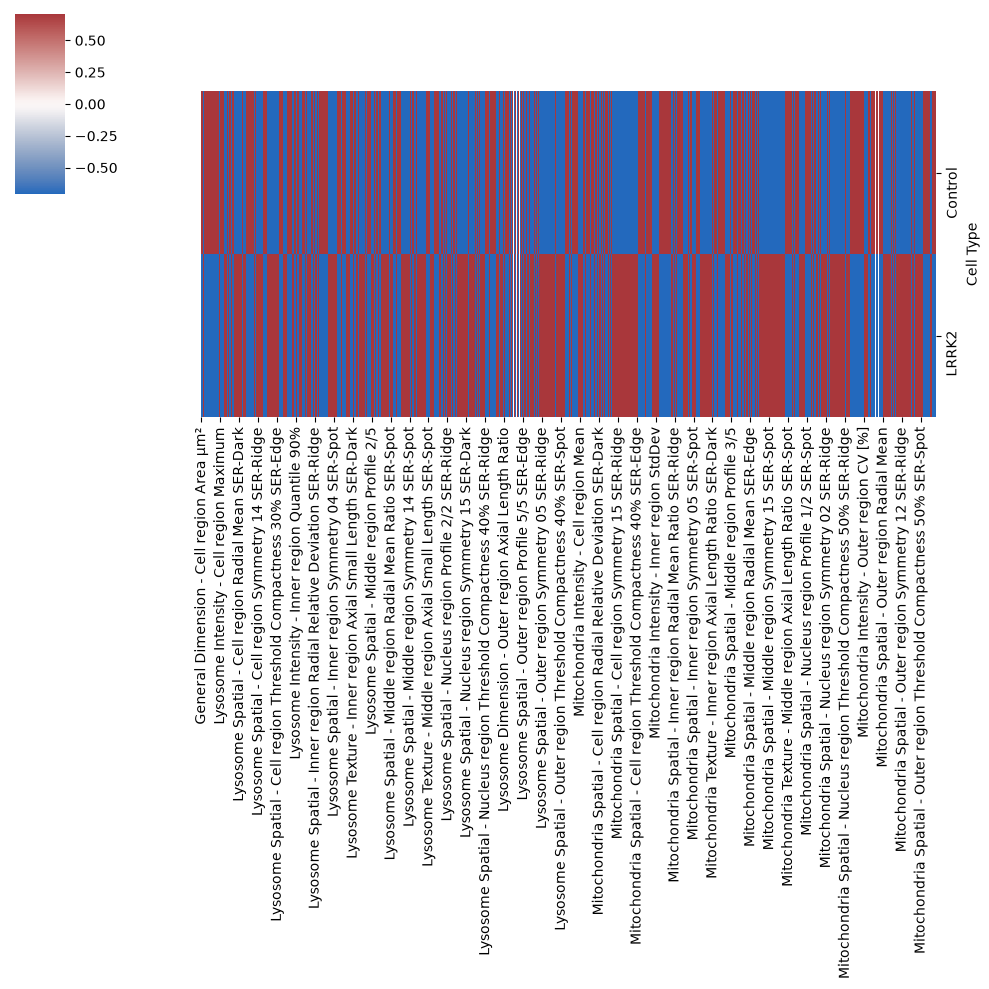

In [18]:
# 4. Plot the Clustered Heatmap
g = sns.clustermap(
    heatmap_data,
    cmap='vlag',
    figsize=(10, 10),
    row_cluster=False,
    col_cluster=False,
    z_score=1,
)

## Begin adding additional labels

In [19]:
set(organelles)

{'General', 'Lysosome', 'Mitochondria'}

In [20]:
set(regions)

{'Cell region',
 'Inner region',
 'Middle region',
 'Nucleus region',
 'Outer region'}

In [21]:
set(star_types)

{'Axial', 'None', 'Radial', 'Symmetry', 'Threshold'}

In [22]:
set(feature_types)

{'Dimension', 'Intensity', 'Spatial', 'Texture'}

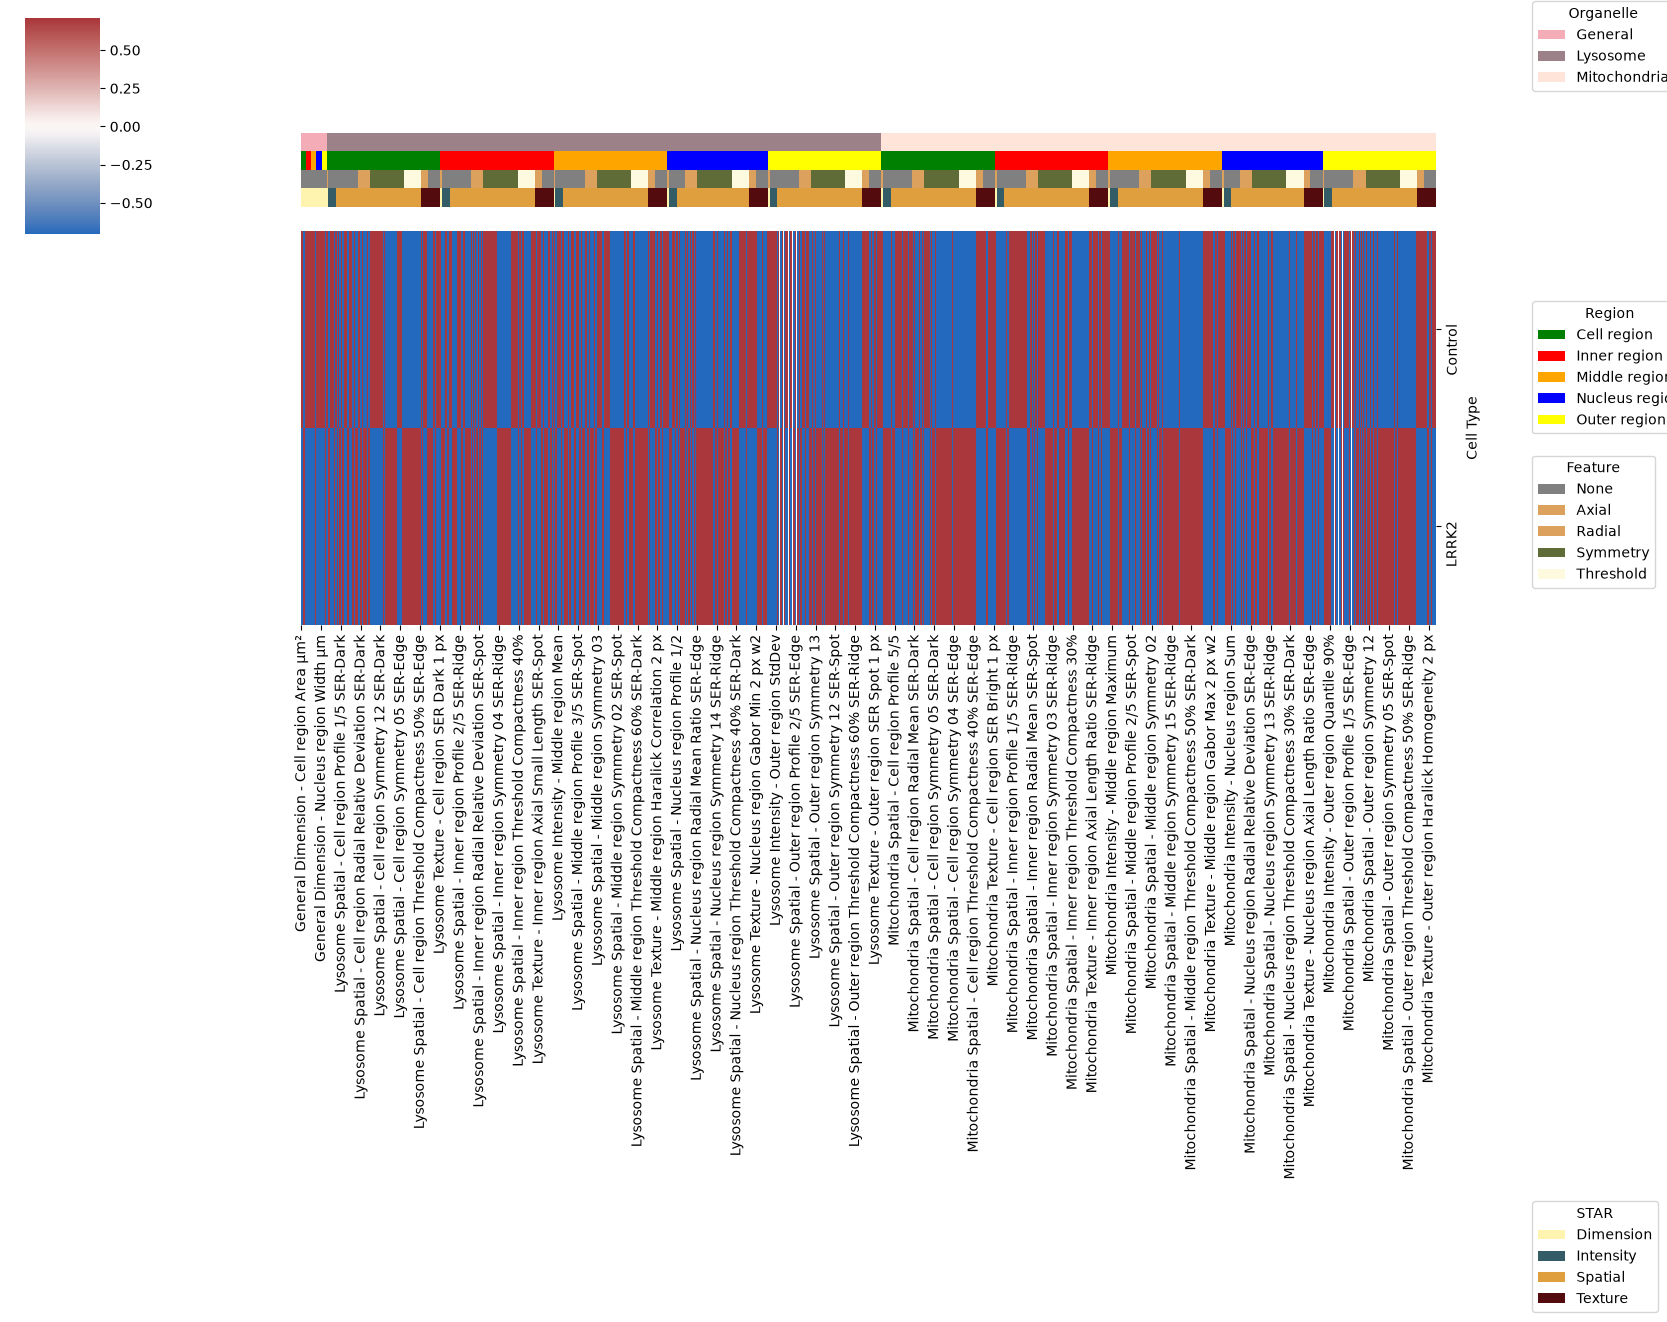

In [23]:
# Initialise an organelles array
organelle_colors = [

]

lut_organelle = {

}

for organelle in organelles:
    color = 'Grey'
    if organelle == 'General':
        color = '#f4acb7'
    elif organelle == 'Mitochondria':
        color = '#ffe5d9'
    else:
        color = '#9d8189'

    lut_organelle[organelle] = color
    organelle_colors.append(color)

# Initialise a colours array
region_colors = [

]

lut = {

}


# Initialise a colours array for STAR
star_colors = [

]

lut_star = {

}
for star in star_types:
    if star == 'None':
        star_color = 'Grey'
    elif star == 'Symmetry':
        star_color = '#606c38'
    elif star == 'Threshold':
        star_color = '#fefae0'
    elif star == 'Axial':
        star_color = '#dda15e'
    else:
        star_color = '#dda15e'

    lut_star[star] = star_color
    star_colors.append(star_color)
    


# Go over each region
for region in regions:
    if region == 'Nucleus region':
        region_color = 'Blue'
        lut['Nucleus region'] = 'Blue'
    elif region == 'Inner region':
        region_color = 'Red'
        lut['Inner region'] = 'Red'
    elif region == 'Middle region':
        region_color = 'Orange'
        lut['Middle region'] = 'Orange'
    elif region == 'Outer region':
        region_color = 'Yellow'
        lut['Outer region'] = 'Yellow'
    elif region == 'Cell region':
        region_color = 'Green'
        lut['Cell region'] = 'Green'

    lut[region] = region_color
    region_colors.append(region_color)

# Feature colours
feature_colours = []
lut_feature = {

}
for feature in feature_types:
    if feature == 'Intensity':
        feature_color = '#335c67'
    elif feature == 'Dimension':
        feature_color = '#fff3b0'
    elif feature == 'Spatial':
        feature_color = '#e09f3e'
    else:
        feature_color = '#540b0e'

    lut_feature[feature] = feature_color

    feature_colours.append(feature_color)


# Figure this legend part out later
handles = [Patch(facecolor=lut[name]) for name in lut]
handles_2 = [Patch(facecolor=lut_star[name]) for name in lut_star]
handles_3 = [Patch(facecolor=lut_feature[name]) for name in lut_feature]
handles_4 = [Patch(facecolor=lut_organelle[name]) for name in lut_organelle]

g = sns.clustermap(
    heatmap_data,
    cmap='vlag',
    figsize=(15, 12),
    row_cluster=False,
    col_cluster=False,
    z_score=1,
    col_colors=[organelle_colors, region_colors, star_colors, feature_colours]
)

pos = g.ax_heatmap.get_position()

# 3. Define how much gap we want to add
gap = 0.02 

g.ax_heatmap.set_position([pos.x0, pos.y0, pos.width, pos.height - gap])

ax= plt.gca()
# 1. First Legend (Organelle) - Top Left of anchor
leg1 = plt.legend(handles_4, lut_organelle, title='Organelle',
                  bbox_to_anchor=(1.02, 1.0), bbox_transform=plt.gcf().transFigure, loc='upper left')
ax.add_artist(leg1) # Pin it so it doesn't get overwritten

# 2. Second Legend (Region) - Shifted down vertically (e.g., to y=0.75)
leg2 = plt.legend(handles, lut, title='Region',
                  bbox_to_anchor=(1.02, 0.75), bbox_transform=plt.gcf().transFigure, loc='upper left')
ax.add_artist(leg2)

# 3. Third Legend (Feature) - Shifted further down (e.g., to y=0.50)
leg3 = plt.legend(handles_2, lut_star, title='Feature',
                  bbox_to_anchor=(1.02, 0.50), bbox_transform=plt.gcf().transFigure, loc='lower left')
ax.add_artist(leg3)
# 4. Fourth Legend (STAR) - Placed at the bottom right corner
leg4 = plt.legend(handles_3, lut_feature, title='STAR',
                  bbox_to_anchor=(1.02, 0.0), bbox_transform=plt.gcf().transFigure, loc='upper left')






In [24]:
heatmap_data = heatmap_data.dropna()

ValueError: The condensed distance matrix must contain only finite values.

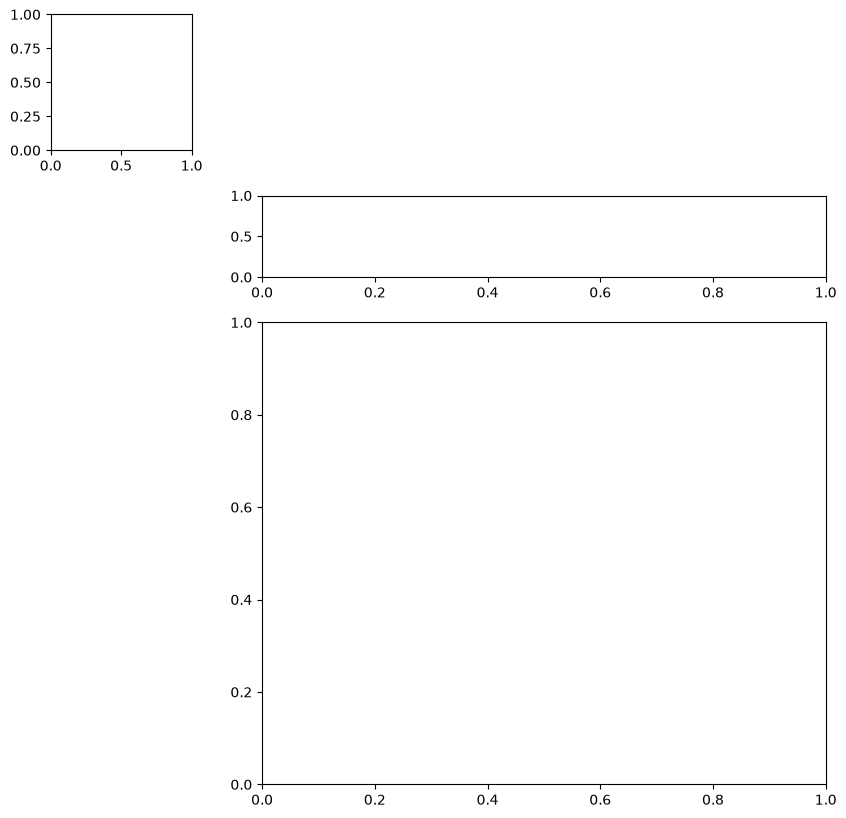

In [25]:
g = sns.clustermap(
    heatmap_data,
    cmap='vlag',
    figsize=(10, 10),
    row_cluster=True,
    col_cluster=False,
    z_score=1,
    metric="euclidean",
    col_colors=[organelle_colors, region_colors, star_colors, feature_colours]
)